# 01 — EDA, Subsampling, and 5-Fold Cross-Validation Splits

This notebook prepares the Jigsaw Toxic Comment dataset for the final project:

1. Exploratory analysis of the full `train.csv`
2. Stratified subsample (25,000 rows) preserving multi-label distribution
3. Fixed 5-fold CV splits shared by BERT and local LLM experiments

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import LABELS, SUBSAMPLE_SIZE, TRAIN_CSV
from src.data_utils import (
    label_distribution,
    load_raw_data,
    preprocess_dataframe,
    prepare_dataset,
)

sns.set_theme(style="whitegrid")
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\yusuf\OneDrive\Desktop\vscode\FuzzyLogic\final


## 1. Load and explore full dataset

In [2]:
raw_df = load_raw_data(TRAIN_CSV)
full_df = preprocess_dataframe(raw_df)

print(f"Full dataset size: {len(full_df):,}")
print(f"Columns: {list(full_df.columns)}")

full_label_dist = label_distribution(full_df)
display(full_label_dist)

full_df["label_count"] = full_df[LABELS].sum(axis=1)
print(f"Comments with any toxic label: {(full_df[LABELS].sum(axis=1) > 0).sum():,}")
print(f"Average labels per comment: {full_df['label_count'].mean():.3f}")

Full dataset size: 159,571
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,label,count,percentage
0,toxic,15294,9.584448
1,severe_toxic,1595,0.999555
2,obscene,8449,5.294822
3,threat,478,0.299553
4,insult,7877,4.936361
5,identity_hate,1405,0.880486


Comments with any toxic label: 16,225
Average labels per comment: 0.220


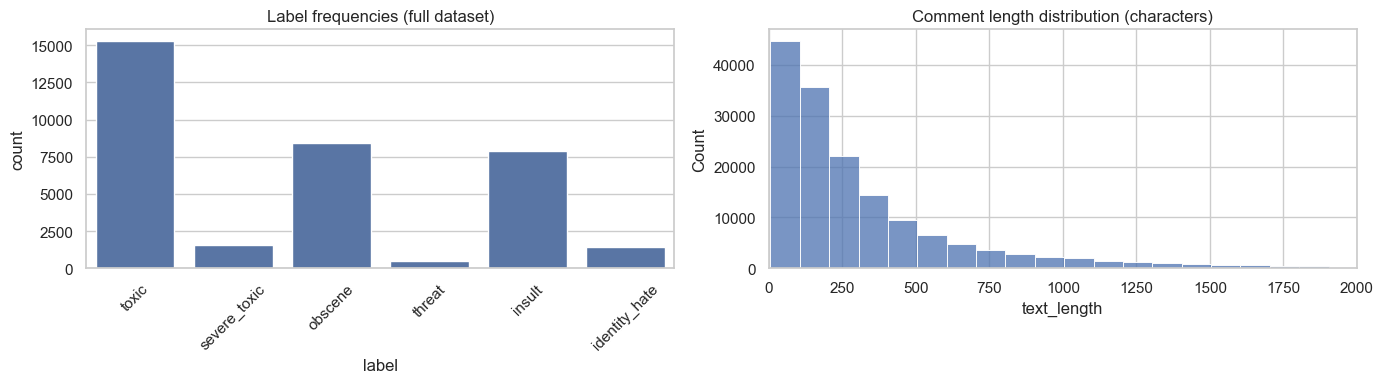

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=full_label_dist, x="label", y="count", ax=axes[0])
axes[0].set_title("Label frequencies (full dataset)")
axes[0].tick_params(axis="x", rotation=45)

full_df["text_length"] = full_df["comment_text"].str.len()
sns.histplot(full_df["text_length"], bins=50, ax=axes[1])
axes[1].set_title("Comment length distribution (characters)")
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

## 2. Stratified subsample (25,000 rows)

We use **multilabel stratified sampling** (`iterative-stratification`) so each label keeps roughly the same proportion as in the full dataset. This keeps BERT training fast and makes local LLM inference feasible on your machine.

In [4]:
sampled_df, folds = prepare_dataset(force_recreate_subsample=True, force_recreate_folds=True)

sampled_label_dist = label_distribution(sampled_df)
comparison = full_label_dist.merge(
    sampled_label_dist,
    on="label",
    suffixes=("_full", "_sample"),
)
comparison["pct_diff"] = (comparison["percentage_sample"] - comparison["percentage_full"]).round(3)
display(comparison)

,label,count_full,percentage_full,count_sample,percentage_sample,pct_diff
0,toxic,15294,9.584448,2396,9.584,-0.000
1,severe_toxic,1595,0.999555,250,1.000,0.000
2,obscene,8449,5.294822,1324,5.296,0.001
3,threat,478,0.299553,75,0.300,0.000
4,insult,7877,4.936361,1234,4.936,-0.000
5,identity_hate,1405,0.880486,220,0.880,-0.000


## 3. Verify 5-fold cross-validation splits

The same fold indices are saved under `data/fold_indices/` and will be reused by both BERT and LLM notebooks.

In [5]:
fold_rows = []
for fold_idx, fold in enumerate(folds):
    fold_rows.append(
        {
            "fold": fold_idx,
            "train": len(fold["train"]),
            "val": len(fold["val"]),
            "test": len(fold["test"]),
        }
    )

fold_summary = pd.DataFrame(fold_rows)
display(fold_summary)

for fold_idx, fold in enumerate(folds):
    test_labels = sampled_df.iloc[fold["test"]][LABELS]
    toxic_rate = test_labels.sum(axis=1).gt(0).mean()
    print(f"Fold {fold_idx}: test toxic rate = {100 * toxic_rate:.2f}%")

,fold,train,val,test
0,0,18000,2000,5000
1,1,18000,2000,5000
2,2,18000,2000,5000
3,3,18000,2000,5000
4,4,18000,2000,5000


Fold 0: test toxic rate = 10.12%
Fold 1: test toxic rate = 10.10%
Fold 2: test toxic rate = 10.28%
Fold 3: test toxic rate = 10.16%
Fold 4: test toxic rate = 10.00%
